In [1]:
import pandas as pd
from pathlib import Path
file_path = "/home/sambray/Documents/c3po/tutorial/c3po_dandi_candidate_datasets_v2.csv"
dataset_df = pd.read_csv(file_path)

dandiset_id = 53

dataset_df = dataset_df[dataset_df['dandiset_id'] == dandiset_id]

dandiset_id = f"{dandiset_id:06d}"
dandi_path = dataset_df['dandi_path'].values[0]
model_dir = Path(f"/stelmo/sam/c3po_dandi_training_v2/{dandiset_id}")

In [2]:
import matplotlib.pyplot as plt
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"  # Disable GPU usage for this example

from pathlib import Path
from dandi.dandiapi import DandiAPIClient
from dandi.consts import known_instances
import fsspec
from fsspec.implementations.cached import CachingFileSystem
import h5py
import pynwb

def get_dandi_file(dandiset_id, dandi_path, dandi_instance="dandi"):
    tmp_dir = "dandi_cache"  # Local folder for cache
    Path(tmp_dir).mkdir(exist_ok=True)  # Create the cache folder if it doesn't exist

    # get the s3 url from Dandi
    with DandiAPIClient(
        dandi_instance=known_instances[dandi_instance],
    ) as client:
        asset = client.get_dandiset(dandiset_id).get_asset_by_path(dandi_path)
        s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)

    # stream the file from s3
    # first, create a virtual filesystem based on the http protocol
    fs = fsspec.filesystem("http")

    # create a cache to save downloaded data to disk (optional)
    fsspec_file = CachingFileSystem(
        fs=fs,
        cache_storage=tmp_dir,  # Local folder for cache
    )

    # Open and return the file
    fs_file = fsspec_file.open(s3_url, "rb")
    io = pynwb.NWBHDF5IO(file=h5py.File(fs_file))
    nwbfile = io.read()
    return io, nwbfile

In [3]:
nwbfile = get_dandi_file(dandiset_id, dandi_path, dandi_instance="dandi")[1]

In [4]:
from c3po.analysis.analysis import C3poAnalysis
import numpy as np
analysis = C3poAnalysis(model_dir=model_dir)
analysis.fit_context_pca()
t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.001)
analysis.interpolate_context(t_interp)
analysis.embed_context_pca()

In [5]:
nwbfile

KeyboardInterrupt: 

In [6]:
obj_id = dataset_df['event_object_id'].values[0]
event_df = nwbfile.objects[obj_id].to_dataframe()
event_df#[:30]

,start_time,stop_time,visual_contrast,running_wheel_gain,reward
id,,,,,
0,22.32720,39.93058,100.0,1.0,True
1,39.93058,57.34003,100.0,1.0,True
2,57.34003,71.69989,100.0,1.0,True
3,71.69989,85.51897,100.0,1.0,True
4,85.51897,99.86709,100.0,1.0,True
...,...,...,...,...,...
208,2536.44900,2592.20600,100.0,1.0,True
209,2592.20600,2603.78700,100.0,1.0,True
210,2603.78700,2614.17900,100.0,1.0,True


In [9]:
result

array([[[ 7.66864946e-01,  1.87309928e+00,  4.85660630e+00, ...,
          6.44961381e-01, -1.56137743e-01,  7.29466335e-02],
        [ 8.62545839e-01,  1.79584500e+00,  4.62477497e+00, ...,
          6.67490301e-01, -1.74276917e-01,  7.62647034e-02],
        [ 9.58226731e-01,  1.71859072e+00,  4.39294364e+00, ...,
          6.90019220e-01, -1.92416091e-01,  7.95827733e-02],
        ...,
        [-1.18207299e+01,  6.03620155e+00,  1.56389129e+00, ...,
          2.10058103e-01,  1.16849481e-01, -1.93942752e-01],
        [-1.20477556e+01,  5.89473407e+00,  1.57627844e+00, ...,
          2.03691189e-01,  1.21068308e-01, -1.91135955e-01],
        [-1.23012818e+01,  5.86034643e+00,  1.58671999e+00, ...,
          1.83027987e-01,  1.03703001e-01, -1.75626590e-01]],

       [[-1.63506383e+00, -9.63173939e-01,  3.04465239e+00, ...,
          2.14253039e-01,  2.13384152e-01,  1.18858178e-01],
        [-1.29002115e+00, -8.69244232e-01,  3.13622822e+00, ...,
          2.53186777e-01,  1.77897227e

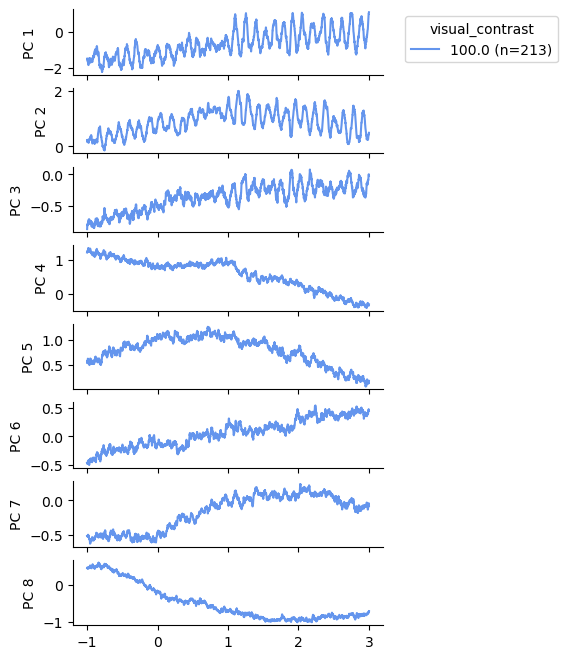

In [13]:
mark = "start_time"
feature = "visual_contrast"
window = (-1,3)

fig, ax = plt.subplots(nrows = 8, sharex=True, figsize=(4,8))
feature_val_list = event_df[feature].unique()
# feature_val_list = [val for val in feature_val_list if "presentation" in val]

for i_feat, feature_val in enumerate(feature_val_list):
    df = event_df[event_df[feature] == feature_val]
    result = analysis.alligned_response(df[mark].values, window, pca=True)
    mid = np.nanmean(result, axis=0)
    # low = np.percentile(result, 25, axis=0)
    # high = np.percentile(result, 75, axis=0)
    if len(feature_val_list) == 1:
        color = "cornflowerblue"
    elif isinstance(feature_val, str):
        color = i_feat / len(feature_val_list)
        color = plt.cm.tab10(color)
    else:
        color = (feature_val - np.min(feature_val_list)) / (np.max(feature_val_list) - np.min(feature_val_list))
        color = plt.cm.viridis(color)
    t_plot = np.linspace(window[0], window[1], mid.shape[0])

    for i, a in enumerate(ax):
        # a.fill_between(t_plot, low[:,i], high[:,i], color=plt.cm.viridis(color), alpha=0.3)
        label = f"{feature_val} (n={len(df)})"
        a.plot(t_plot, mid[:,i], color=color, label=label)
        a.set_ylabel(f"PC {i+1}")
        a.spines[['top', 'right']].set_visible(False)
ax[0].legend(title=feature, bbox_to_anchor=(1.05, 1), loc='upper left')

In [ ]:
fingers = event_df['finger'].unique()
directions = event_df['cue_location'].unique()

n_pc = 4
fig, ax_list = plt.subplots(ncols = len(fingers),nrows = n_pc,
                            sharex=True,
                            figsize=(4*len(fingers),4*n_pc))

for i_finger, finger in enumerate(fingers):
    df = event_df[event_df['finger'] == finger]
    for i_dir, direction in enumerate(directions):
        df_dir = df[df['cue_location'] == direction]
        result = analysis.alligned_response(df_dir[mark].values, window, pca=True)
        mid = np.mean(result, axis=0)
        low = np.percentile(result, 25, axis=0)
        high = np.percentile(result, 75, axis=0)
        color = i_dir / len(directions)
        color = plt.cm.tab10(color)
        t_plot = np.linspace(window[0], window[1], mid.shape[0])
        for i_pc in range(n_pc):
            a = ax_list[i_pc,i_finger]
            a.fill_between(t_plot, low[:,i_pc], high[:,i_pc], color=color, alpha=0.3)
            label = f"{direction} (n={len(df_dir)})"
            a.plot(t_plot, mid[:,i_pc], color=color, label=label)
            a.set_ylabel(f"PC {i_pc+1}")
            a.spines[['top', 'right']].set_visible(False)

In [69]:
nwbfile.processing['behavior']

Data type,float64
Shape,"(127222, 2)"
Array size,1.94 MiB
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),2035552
Compressed size (bytes),2035552
Compression ratio,1.0
Data type,float64
Shape,"(127222,)"


In [89]:
# data_obj = nwbfile.processing['behavior']['eye_velocity']
data_obj = nwbfile.processing['behavior']['EyeTracking']['eye_position']
t = data_obj.timestamps[:]
data = data_obj.data[:]
s1 =5
s2 = s1
n1 = 20
n2 = n1
bb1 = np.linspace(-s1,s1, n1)
bb2 = np.linspace(-s2,s2, n2)
H, bx, by = analysis.bin_context_by_feature_2d(
    feature_1 = data[:,0],  # horizontal eye velocity
    feature_1_times = t,
    feature_2 = data[:,1],  # vertical eye velocity
    feature_2_times = t,
    pca=True,
    bins_1 = bb1,
    bins_2 = bb2,
    interpolated = False
)

# nwbfile

In [90]:
mid = np.zeros((len(H), len(H[0]), 16))

for i in range(len(H)):
    for j in range(len(H[0])):
        mid[i,j,:] = np.nanmedian(H[i][j], axis=0)

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/tmp/ipykernel_948034/4014074024.py:5: RuntimeWarning: All-NaN slice encountered
  mid[i,j,:] = np.nanmedian(H[i][j], axis=0)


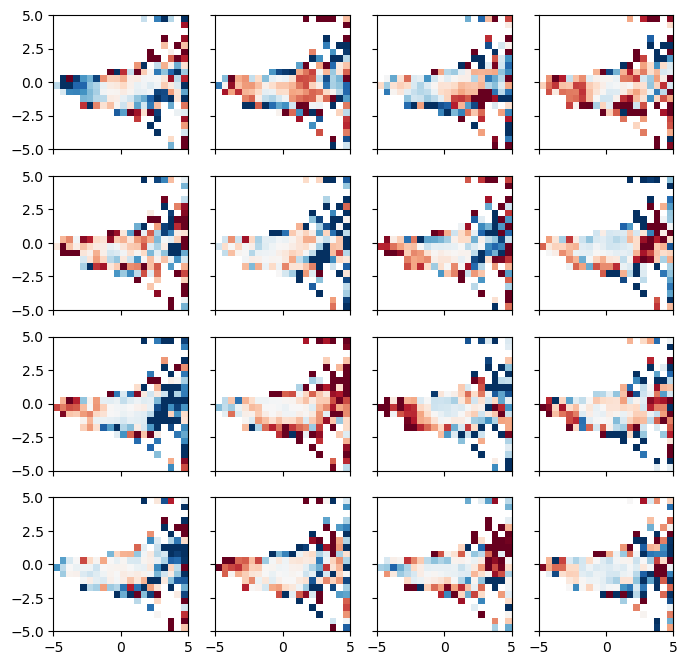

In [91]:
fig, ax = plt.subplots(nrows = 4, ncols = 4, sharex=True, sharey=True, figsize=(8,8))
for i, a in enumerate(ax.flatten()):
    val = mid[:,:,i].T
    v = np.nanpercentile(np.abs(val),80)
    a.imshow(val, cmap="RdBu",  extent=[bb1[0], bb1[-1], bb2[0], bb2[-1]], origin='lower',
             aspect='auto',clim=(-v,v))


In [126]:
data_obj = nwbfile.processing['behavior']['EyeTracking']['eye_position']
data_obj = nwbfile.processing['behavior']['eye_velocity']
t = data_obj.timestamps[:]
data = data_obj.data[:,1]

sc = 2
bins = np.linspace(-sc,sc, 30)
results, bins = analysis.bin_context_by_feature(
    feature = data,
    feature_times = t,
    bins = bins,
    interpolated = False
)
mid = np.array([np.nanmedian(r, axis=0) for r in results])
low = np.array([np.nanpercentile(r, 25, axis=0) for r in results])
high = np.array([np.nanpercentile(r, 75, axis=0) for r in results])

(-2.0, 2.0)

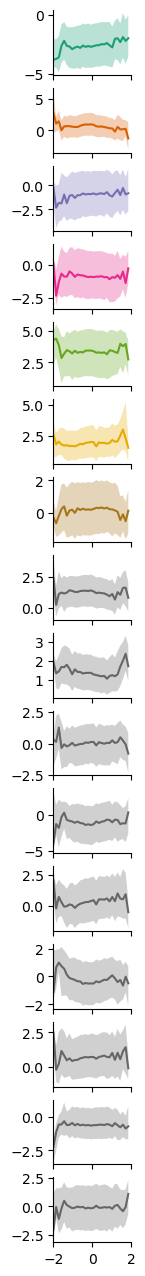

In [127]:
n_pc = 16
fig, ax = plt.subplots(nrows = n_pc, ncols = 1, sharex=True, figsize=(1,1*n_pc))
for i in range(n_pc):
    color  = plt.cm.Dark2(i/8)
    ax[i].plot(bins[:-1], mid[:,i], color=color)
    ax[i].fill_between(bins[:-1], low[:,i], high[:,i], facecolor=color, alpha=0.3)
    ax[i].spines[['top', 'right']].set_visible(False)
plt.xlim(-sc,sc)

In [106]:
data_obj

Data type,float64
Shape,"(127222, 2)"
Array size,1.94 MiB
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),2035552
Compressed size (bytes),2035552
Compression ratio,1.0
Data type,float64
Shape,"(127222,)"


## info

In [15]:
dataset_df.publication_source.values[0]

'https://www.nature.com/articles/s41467-021-20936-8'

In [14]:
import yaml
yaml_path = model_dir / "metrics.yaml"
metrics = yaml.safe_load(open(yaml_path, "r"))
metrics

{'dimensions': 16,
 'mua_rate': 550.7076002817464,
 'n_units': 77,
 'training_time': 836.3123989105225}